### 3-6. 손글씨 숫자 인식
###### 학습 과정은 생략하고 추론 과정만 구현
---

In [30]:
import sys, os
sys.path.append(os.pardir) 
from dataset.mnist import load_mnist


(x_train, t_train), (x_test, t_test) = load_mnist(flatten=True, normalize=False)


print(x_train.shape) 
print(t_train.shape) 
print(x_test.shape)  
print(t_test.shape)  

Converting train-images-idx3-ubyte.gz to NumPy Array ...
Done
Converting train-labels-idx1-ubyte.gz to NumPy Array ...
Done
Converting t10k-images-idx3-ubyte.gz to NumPy Array ...
Done
Converting t10k-labels-idx1-ubyte.gz to NumPy Array ...
Done
Creating pickle file ...
Done!
(60000, 784)
(60000,)
(10000, 784)
(10000,)


In [33]:
import sys,os
sys.path.append(os.pardir)
import numpy as np
from dataset.mnist import load_mnist
from PIL import Image

def img_show(img):
    pil_img = Image.fromarray(np.uint8(img))
    pil_img.show()

(x_train, t_train), (x_test, t_test) = load_mnist(flatten = True, normalize = False)

img = x_train[0]
label = t_train[0]
print(label)

print(img.shape)
img = img.reshape(28, 28) # flatten으로 바뀐 배열의 모양을 다시 이미지 배열을 다시 28 * 28로 맞춘다.
print(img.shape)

img_show(img)

5
(784,)
(28, 28)


- *pickle이라는 기능을 이용해서 프로그램 실행 중에 특정 객체를 파일로 저장해서 다음 사용부터는 짧은 시간에 이용한다!!

In [ ]:
# 신경망의 추론 처리
# 입력층 뉴런: 784개(28 * 28), 출력층 뉴런: 10개(0에서 9까지의 숫자를 구분하는 문제이기 때문)
# 은닝층은 총 두 개 (첫 번째 은닉층: 뉴런 50개, 두 번째 은닉층: 뉴런 100개 임의 설정)

import sys,os
import pickle
sys.path.append(os.pardir)
import numpy as np
from dataset.mnist import load_mnist
from PIL import Image


def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def softmax(x):
    c = np.max(x)
    exp_a = np.exp(x - c)
    sum_exp_a = np.sum(exp_a)
    y = exp_a / sum_exp_a
    
    return y


def get_data():
    (x_train, t_train), (x_test, t_test) = load_mnist(flatten = True, normalize = False)
    return x_test, t_test


def init_network(): # pickle을 이용해서 학습되어 있는 파일의 가중치 값을 받아온다.
    with open("sample_weight.pkl", 'rb') as f:
        network = pickle.load(f)

    return network


def predict(network, x):
    W1, W2, W3 = network['W1'], network['W2'], network['W3']
    b1, b2, b3 = network['b1'], network['b2'], network['b3']

    a1 = np.dot(x, W1) + b1
    z1 = sigmoid(a1)
    a2 = np.dot(z1, W2) + b2
    z2 = sigmoid(a2)
    a3 = np.dot(z2, W3) + b3
    y = softmax(a3) 

    return y


x, t = get_data()
network = init_network()


accuracy_cnt = 0
for i in range(len(x)):
    y = predict(network, x[i])
    p = np.argmax(y)
    if p == t[i]:
        accuracy_cnt += 1

print("Accuracy:" + str(float(accuracy_cnt) / len(x)))




Accuracy:0.9207


/tmp/ipykernel_81489/3202646233.py:14: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-x))


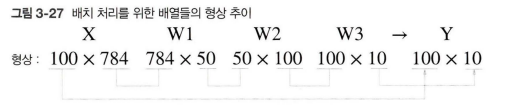

- 배치 처리를 위한 배열들의 형상 추이
- 100장의 이미지가 입력으로 들어갔을 때 0부터 9까지 숫자를 구분하는 softmax 확률이 100장 나온다.
##### *배치: 하나로 묶은 입력 데이터



- 배치를 쓰는 이유:

1. CPU/GPU는 큰 배열 계산에 최적화되어 있다.(GPU는 원래 같은 계산을 엄청 많이 동시에 하는 장치)
2. 데이터 전송 시간이 줄어든다.

In [ ]:
# batch를 이용한 추론
import sys,os
import pickle
sys.path.append(os.pardir)
import numpy as np
from dataset.mnist import load_mnist
from PIL import Image


def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def softmax(x):
    c = np.max(x)
    exp_a = np.exp(x - c)
    sum_exp_a = np.sum(exp_a)
    y = exp_a / sum_exp_a
    
    return y


def get_data():
    (x_train, t_train), (x_test, t_test) = load_mnist(flatten = True, normalize = False)
    return x_test, t_test


def init_network(): # pickle을 이용해서 학습되어 있는 파일의 가중치 값을 받아온다.
    with open("sample_weight.pkl", 'rb') as f:
        network = pickle.load(f)

    return network


def predict(network, x):
    W1, W2, W3 = network['W1'], network['W2'], network['W3']
    b1, b2, b3 = network['b1'], network['b2'], network['b3']

    a1 = np.dot(x, W1) + b1
    z1 = sigmoid(a1)
    a2 = np.dot(z1, W2) + b2
    z2 = sigmoid(a2)
    a3 = np.dot(z2, W3) + b3
    y = softmax(a3) 

    return y

x, t = get_data()
network = init_network()

batch_size = 100
accuracy_cnt = 0

for i in range(0, len(x), batch_size):
    x_batch = x[i:i+batch_size] # x[0:100], x[100:200] ....으로 간다.
    y_batch = predict(network, x_batch)
    p = np.argmax(y_batch, axis = 1)
    accuracy_cnt += np.sum(p == t[i:i+batch_size])

print("Accuracy" + str(float(accuracy_cnt) / len(x)))



Accuracy0.9207


/tmp/ipykernel_81489/514502361.py:11: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-x))


### 정리

- 신경망에서는 활성화 함수로 시그모이드 함수와 ReLU 함수 같은 매끄럽게 변화하는 함수를 이용한다.

- 기계학습 문제는 크게 회귀와 분류로 나눌 수 있다.(주로 회귀에서는 항등 함수, 분류에서는 소프트맥스 함수)

- 분류에서는 출력층의 뉴런 수를 분류하려는 클래스 수와 같게 설정한다.

- 입력 데이터를 묶은 것을 배치라 하며, 추론 처리를 이 배치 단위로 진행하면 결과를 훨씬 빠르게 얻을 수 있다.